In [1]:
import numpy as np
from numpy.linalg import inv as inv
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.datasets import make_spd_matrix
from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from scipy.stats import chi2
from scipy.stats import multivariate_normal
from scipy.optimize import minimize

from numpy.lib.stride_tricks import sliding_window_view

from statsmodels.stats.multitest import fdrcorrection
from statsmodels.tsa.seasonal import STL

import cvxpy as cp

%matplotlib inline

# fix random seed
np.random.seed(39)

import warnings
warnings.filterwarnings('ignore')  # <- remember to comment this if something breaks and you get confused

In [2]:
def is_pos_def(A):
    if is_symmetric(A):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

def is_symmetric(a, tol=1e-8):
    return np.all(np.abs(a-a.T) < tol)

In [3]:
def generate_matrices_orthogonal(prec_coeffs=None, M=2, dim=4):
    H_s = []
    if not prec_coeffs:
        prec_coeffs = np.random.rand(M)
    precision = np.zeros((dim, dim))
    H_s_stacked = np.zeros((dim**2, M))
    mat = make_spd_matrix(dim)
    indxes = np.random.choice(np.arange(dim), (M, dim//M), replace=False)
    for i in range(M):
        A = np.zeros((dim, dim))
        for idx in indxes[i]:
            for idx2 in indxes[i]:
                A[idx, idx2] = mat[idx, idx2]
        H_s.append(A)
        precision += prec_coeffs[i]*A
        H_s_stacked[:, i] = A.flatten()
    H_s = np.array(H_s)
    
    # ensure basis matrices are linearly independent
    assert np.linalg.matrix_rank(H_s_stacked) == M, "Not Linearly Independent basis matrices"
    
    # ensure it's actually symmetric
    # minimal modification on scale of 1e-15
    precision_corrected = (precision + precision.T)/2
    
    return H_s, precision_corrected, prec_coeffs

def collect_precision_matrix(H_s, prec_coeffs):
    precision = (prec_coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    
    return precision

def sim_changepoint_mv_normal_orthogonal(M=2, dim=4, N=500):
    assert dim % M == 0, "Need dim divisible by M for sake of sampling at the moment"
    H_s, precision_one, prec_coeffs_one = generate_matrices_orthogonal(M=M, dim=dim)
    data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)
    
    prec_coeffs_two = prec_coeffs_one.copy()
    prec_coeffs_two[0] += 0.2
    precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
    data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)
    
    data_total = np.concatenate((data_one, data_two), axis=1)
    C_total = np.cov(data_total)
    
    return H_s, data_total

def sim_changepoint_mv_normal_orthogonal_mult_coeff(M=2, dim=4, N=500, num_coeffs_change=1):
    assert dim % M == 0, "Need dim divisible by M for sake of sampling at the moment"
    H_s, precision_one, prec_coeffs_one = generate_matrices_orthogonal(M=M, dim=dim)
    data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)
    
    assert num_coeffs_change <= M, "Cannot change more coefficients than exist"
    
    # multiple coeffs to change - sample them randomly
    to_change_coeffs = np.random.choice(np.arange(M), num_coeffs_change, replace=False)
    prec_coeffs_two = prec_coeffs_one.copy()
    for i in range(num_coeffs_change):
        prec_coeffs_two[to_change_coeffs[i]] += np.random.uniform(0.1, 0.3, 1)[0]
        
    precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
    data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)
    
    data_total = np.concatenate((data_one, data_two), axis=1)
    C_total = np.cov(data_total)
    print("Precision Coefficients Pre-Changepoint: ", prec_coeffs_one)
    print("Precision Coefficients Post-Changepoint: ", prec_coeffs_two)
    
    return H_s, data_total

def sim_data(covar, dim, N=1000):
    assert is_symmetric(covar), is_pos_def(covar)
    data_sim = np.random.multivariate_normal(np.zeros(dim), covar, N).T
    data_sim = data_sim - data_sim.mean()
    C = np.cov(data_sim)
    
    return data_sim, C

In [4]:
stock_files = os.path.join("/home/dink/Documents/Research/data/stocks", "*.csv")
stock_list = glob.glob(stock_files)

In [5]:
dfs = []
for filename in stock_list:
    sample_df = pd.read_csv(filename)
    head_tail = os.path.split(filename)
    stock_name = head_tail[1].split('.')[0]
    sample_df['Stock'] = ''.join(stock_name)
    dfs.append(sample_df)


df = pd.concat(dfs, axis=0, ignore_index=True)
df = df.loc[:, ["Date", "Close", "Stock"]]
df = df.pivot(index="Date", columns="Stock", values="Close")

In [6]:
df.head()

Stock,AMC,CLX,ETSY,FB,GME,NFLX,NVDA,PFE,PYPL,SPY,TSLA,TSM
Date,,,,,,,,,,,,
2017-02-22,31.350000,135.919998,12.90,136.119995,26.260000,143.860001,27.690001,31.869070,42.419998,236.279999,54.702000,32.070000
2017-02-23,31.350000,135.830002,12.51,135.360001,25.559999,142.779999,25.122499,32.314991,42.529999,236.440002,51.198002,31.750000
2017-02-24,31.400000,136.369995,12.72,135.440002,26.280001,143.250000,25.365000,32.504745,43.070000,236.740005,51.400002,31.920000
2017-02-27,31.450001,136.440002,12.79,136.410004,26.520000,143.410004,26.102501,32.523720,42.639999,237.110001,49.245998,31.530001
2017-02-28,31.350000,136.809998,12.12,135.539993,24.440001,142.130005,25.370001,32.371918,42.000000,236.470001,49.998001,31.469999


In [7]:
seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(df.shape[1])):
    model = STL(df.values[:, i], period=252) # very approximate seasonality here, holidays+weekends etc
    result = model.fit()
    seasonal_df[df.columns[i]] = result.seasonal
    trend_df[df.columns[i]] = result.trend
    resid_df[df.columns[i]] = result.resid
seasonal_df.index = df.index
trend_df.index = df.index
resid_df.index = df.index

  0%|          | 0/12 [00:00<?, ?it/s]

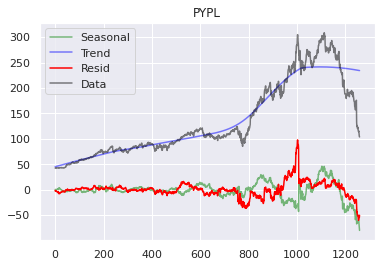

In [8]:
plot_idx = 8
plt.plot(seasonal_df.values[:, plot_idx], color='green', label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, plot_idx], color='blue', label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, plot_idx], color='red', label='Resid')
plt.plot(df.values[:, plot_idx], color='black', label='Data', alpha=0.5)
plt.title(seasonal_df.columns[plot_idx]);
plt.legend(loc='best');

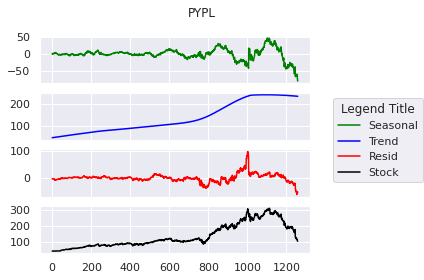

In [9]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)

line_labels = ['Seasonal', 'Trend', 'Resid', 'Stock']
l1 = ax1.plot(seasonal_df.values[:, plot_idx], color='green')
l2 = ax2.plot(trend_df.values[:, plot_idx], color='blue')
l3 = ax3.plot(resid_df.values[:, plot_idx], color='red')
l4 = ax4.plot(df.values[:, plot_idx], color='black')
fig.legend([l1, l2, l3, l4],     # The line objects
           labels=line_labels,   # The labels for each line
           loc="center right",   # Position of legend
           borderaxespad=0.1,    # Small spacing around legend box
           title="Legend Title"  # Title for the legend
           )
plt.subplots_adjust(right=0.75)
plt.suptitle(seasonal_df.columns[plot_idx]);

In [10]:
from sklearn import covariance, preprocessing

scaler = preprocessing.StandardScaler()
resid_scaled = scaler.fit_transform(resid_df.values)
resid_scaled

array([[ 0.85993209, -0.37871229,  0.35322936, ...,  0.34652282,
         0.28819412,  0.16827596],
       [ 0.77310692, -0.48900819,  0.25675531, ...,  0.14818307,
         0.16319952, -0.0147026 ],
       [ 0.70714191, -0.5432549 ,  0.37580764, ..., -0.08262176,
         0.09169055, -0.07948732],
       ...,
       [-1.19769812,  0.09944201, -2.54901867, ..., -1.23978161,
        -1.52467664, -2.01055348],
       [-1.27634945,  0.3779115 , -2.87072812, ..., -1.44433738,
        -1.76973203, -2.34062276],
       [-1.4421088 ,  0.52021097, -2.61035018, ..., -1.40785075,
        -1.33256118, -2.11411572]])

In [11]:
resid_scaled.shape

(1259, 12)

In [11]:
resid_scaled.mean(axis=0), resid_scaled.std(axis=0)

(array([ 0.00000000e+00,  1.69311216e-17,  2.25748288e-17, -3.38622432e-17,
        -2.82185360e-17,  0.00000000e+00, -9.02993151e-17,  2.25748288e-17,
        -1.04408583e-16, -2.25748288e-17,  0.00000000e+00,  7.90119007e-17]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

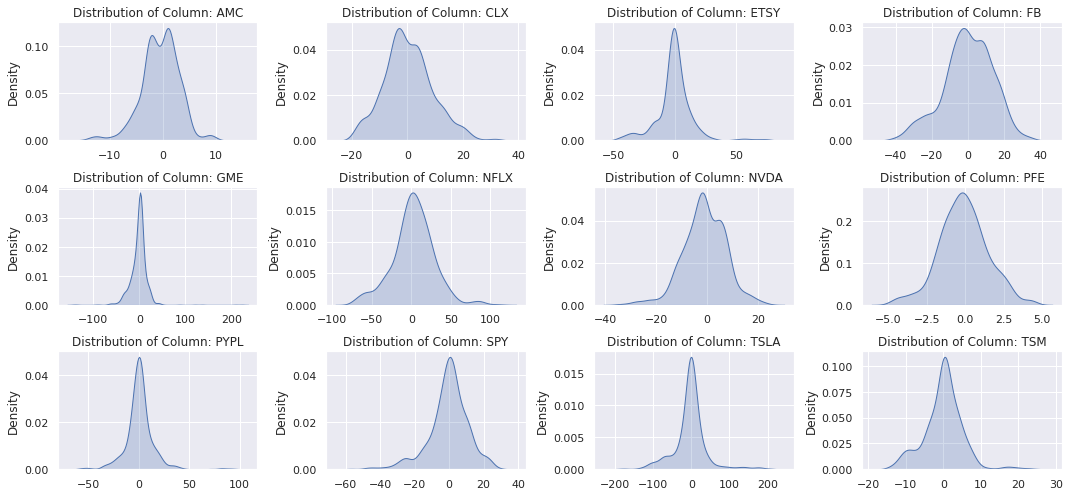

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 7), sharex=False, sharey=False)
axes = axes.ravel()  # array to 1D
cols = resid_df.columns  # create a list of dataframe columns to use

for col, ax in zip(cols, axes):
    data = resid_df[[col]]  # select the data
    sns.kdeplot(data=data, x=col, shade=True, ax=ax)
    ax.set(title=f'Distribution of Column: {col}', xlabel=None)
    
fig.tight_layout()
plt.show()

In [13]:
lam = 1e-3


# fit GraphicalLasso on FIRST HALF(-ish) of data - up to XMAS 2019
#ret = GraphicalLasso(max_iter=1000, alpha=0.01, tol=1e-8).fit(resid_scaled[0:715, :])

# or the whole thing? Sure...

ret = GraphicalLasso(max_iter=1000, alpha=lam, tol=1e-8).fit(resid_scaled)

precision = ret.precision_.copy()
clust_dist_mat = np.abs(precision)
np.fill_diagonal(clust_dist_mat, 0.0)
clust_dist_mat = clust_dist_mat.max() - clust_dist_mat
np.fill_diagonal(clust_dist_mat, 0.0)

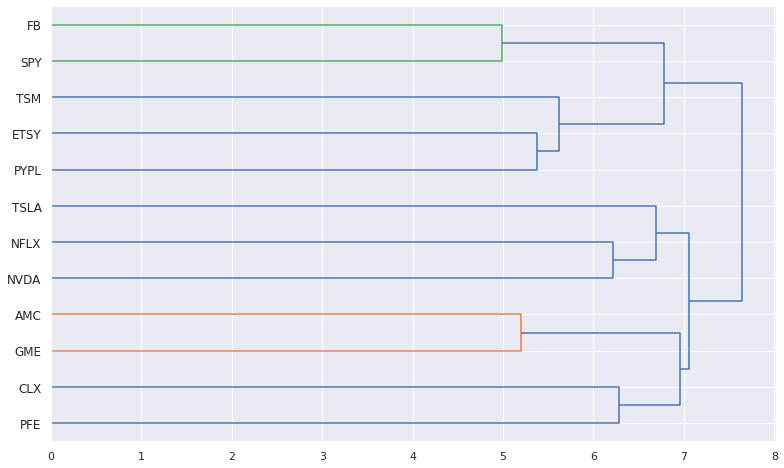

In [14]:
pairwise_distances = sch.distance.pdist(clust_dist_mat)
Z = linkage(pairwise_distances,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(13, 8))
dendrogram(
            Z,
            orientation='right',
            labels=resid_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [15]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=2).squeeze()
cutree1, resid_df.columns

(array([0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1]),
 Index(['AMC', 'CLX', 'ETSY', 'FB', 'GME', 'NFLX', 'NVDA', 'PFE', 'PYPL', 'SPY',
        'TSLA', 'TSM'],
       dtype='object'))

In [16]:
prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2].copy() # set i,j entry to be the entry from precision matrix for given cluster
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)
basis_matrices.shape

(2, 12, 12)

In [17]:
leftover_basis_matrix = precision - basis_matrices.sum(axis=0)

In [18]:
basis_matrices_full = np.concatenate((basis_matrices, np.expand_dims(leftover_basis_matrix, 0)), 0)
basis_matrices_full.sum(axis=0) == ret.precision_

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True

In [19]:
assert is_pos_def(basis_matrices_full.sum(axis=0)), "Not PosDef"
assert is_pos_def(basis_matrices.sum(axis=0)), "Not PosDef"
for mat in basis_matrices_full:
    assert is_symmetric(mat), "Not Symmetric"

In [83]:
H_s = basis_matrices_full.copy()
#H_s = basis_matrices.copy()
M = H_s.shape[0]
dim = H_s.shape[-1]
window_size = 20
data_total = resid_scaled.T
print(M, dim)

3 12


In [84]:
data_total.shape

(12, 1259)

In [85]:
C_full = np.cov(data_total, bias=True)
C_full.shape

(12, 12)

In [86]:
alphas = cp.Variable(shape=(M, ))
psi_hat = sum([alphas[i]*H_s[i] for i in range(M)])
l1_penalty = sum([cp.abs(psi_hat[i, j])
                  for i in range(dim)
                  for j in range(dim) if i != j])
objective = cp.Maximize(cp.log_det(psi_hat) - cp.trace(psi_hat@C_full) - lam*l1_penalty)
constr1 = (psi_hat >> 0)
constr2 = (psi_hat == psi_hat.T)
constraints = [constr1, constr2]
problem = cp.Problem(objective, constraints)
problem.solve()
if problem.status != cp.OPTIMAL:
    raise Exception('CVXPY Error')
alphas.value

array([0.99999937, 0.99994578, 0.99998651])

In [87]:
"""
Try with first half-ish of data, fixed H_s

See what happens?
"""
data_one = data_total[:, 0:650]
C_one = np.cov(data_one, bias=True)

In [88]:
"""
First half optim
"""

alphas = cp.Variable(shape=(M, ))
psi_hat = sum([alphas[i]*H_s[i] for i in range(M)])
l1_penalty = sum([cp.abs(psi_hat[i, j])
                  for i in range(dim)
                  for j in range(dim) if i != j])
objective = cp.Maximize(cp.log_det(psi_hat) - cp.trace(psi_hat@C_one) - lam*l1_penalty)
constr1 = (psi_hat >> 0)
constr2 = (psi_hat == psi_hat.T)
constraints = [constr1, constr2]
problem = cp.Problem(objective, constraints)
problem.solve()
if problem.status != cp.OPTIMAL:
    raise Exception('CVXPY Error')
alphas.value

array([1.46607674, 1.57045833, 1.06322994])

In [89]:
"""
Try with second half-ish of data, fixed H_s

See what happens now?
"""
data_two = data_total[:, 650:]
C_two = np.cov(data_two, bias=True)

In [90]:
"""
First half optim
"""

alphas = cp.Variable(shape=(M, ))
psi_hat = sum([alphas[i]*H_s[i] for i in range(M)])
l1_penalty = sum([cp.abs(psi_hat[i, j])
                  for i in range(dim)
                  for j in range(dim) if i != j])
objective = cp.Maximize(cp.log_det(psi_hat) - cp.trace(psi_hat@C_two) - lam*l1_penalty)
constr1 = (psi_hat >> 0)
constr2 = (psi_hat == psi_hat.T)
constraints = [constr1, constr2]
problem = cp.Problem(objective, constraints)
problem.solve()
if problem.status != cp.OPTIMAL:
    raise Exception('CVXPY Error')
alphas.value

array([0.76364576, 0.73902484, 0.78554108])

In [91]:
def likelihood_ratio_test(likelihood_null, likelihood_alternative, dof):
    delta_d = -2*(likelihood_null-likelihood_alternative)
    
    return delta_d, chi2.pdf(delta_d, dof)


def optimize_coeffs(H_s, C, lam=1e-2):
    alphas = cp.Variable(shape=(H_s.shape[0], ))
    psi_hat = sum([alphas[i]*H_s[i] for i in range(M)])
    l1_penalty = sum([cp.abs(psi_hat[i, j])
                  for i in range(dim)
                  for j in range(dim) if i != j])
    objective = cp.Maximize(cp.log_det(psi_hat) - cp.trace(psi_hat@C) - lam*l1_penalty)
    constr1 = (psi_hat >> 0)
    constr2 = (psi_hat == psi_hat.T)
    problem = cp.Problem(objective, constraints)
    problem.solve()
    if problem.status != cp.OPTIMAL:
        raise Exception('CVXPY Error')
        
    return alphas.value
    
# this is maximized likelihood, not NLL
def lasso_likelihood(alphas, H_s, C, lam=1e-2, include_l1=False):
    psi_hat = sum([alphas[i]*H_s[i] for i in range(H_s.shape[0])])
    l1_penalty = sum([np.abs(psi_hat[i, j])
                  for i in range(C.shape[0])
                  for j in range(C.shape[1]) if i != j])
    
    if include_l1:
        return np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C) - lam*l1_penalty
    
    else:
        return np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C)
    
def full_likelihood(alphas, H_s, C, N, lam=1e-2, include_l1=False):
    P = C.shape[0]
    psi_hat = sum([alphas[i]*H_s[i] for i in range(H_s.shape[0])])
    l1_penalty = sum([np.abs(psi_hat[i, j])
                  for i in range(C.shape[0])
                  for j in range(C.shape[1]) if i != j])
    
    if include_l1:
        likelihood = np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C) - lam*l1_penalty - P*np.log(2*np.pi)
        return likelihood*(N/2)
    
    else:
        likelihood = np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C) - P*np.log(2*np.pi)
        return likelihood*(N/2)
    

###################
def LRT_all_coeffs(data_total, M, dim, H_s, window_size=500, lam=1e-2):
    lrt_vals = []
    p_vals = []
    step_size = 50
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, step_size)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)

        coeffs_hat_one = optimize_coeffs(H_s, C_one, lam=lam)
        coeffs_hat_two = optimize_coeffs(H_s, C_two, lam=lam)
        coeffs_hat_total = optimize_coeffs(H_s, C_full, lam=lam)
        null_first = lasso_likelihood(coeffs_hat_total, H_s, C_one, lam=lam)
        null_second = lasso_likelihood(coeffs_hat_total, H_s, C_two, lam=lam)
        null_likelihood = null_first + null_second
        alt_likelihood_one = lasso_likelihood(coeffs_hat_one, H_s, C_one, lam=lam)
        alt_likelihood_two = lasso_likelihood(coeffs_hat_two, H_s, C_two, lam=lam)
            
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals


def LRT_all_coeffs_full_likelihood(data_total, M, dim, H_s, window_size=500, lam=1e-2):
    lrt_vals = []
    p_vals = []
    step_size = 50
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, step_size)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)

        coeffs_hat_one = optimize_coeffs(H_s, C_one, lam=lam)
        coeffs_hat_two = optimize_coeffs(H_s, C_two, lam=lam)
        coeffs_hat_total = optimize_coeffs(H_s, C_full, lam=lam)
        null_first = full_likelihood(coeffs_hat_total, H_s, C_one, N=data_one.shape[1], 
                                     lam=lam, include_l1=False)
        null_second = full_likelihood(coeffs_hat_total, H_s, C_two, N=data_two.shape[1], 
                                     lam=lam, include_l1=False)
        null_likelihood = null_first + null_second
        alt_likelihood_one = full_likelihood(coeffs_hat_one, H_s, C_one, N=data_one.shape[1], 
                                     lam=lam, include_l1=False)
        alt_likelihood_two = full_likelihood(coeffs_hat_two, H_s, C_two, N=data_two.shape[1], 
                                     lam=lam, include_l1=False)
            
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals
######################

In [92]:
lrt_vals, p_vals = LRT_all_coeffs(data_total, M=M, dim=dim, H_s=H_s, window_size=window_size, lam=lam)
# lrt_vals, p_vals = LRT_all_coeffs_full_likelihood(data_total, M=M, dim=dim, H_s=H_s, 
#                                                   window_size=window_size, lam=lam)

  0%|          | 0/25 [00:00<?, ?it/s]

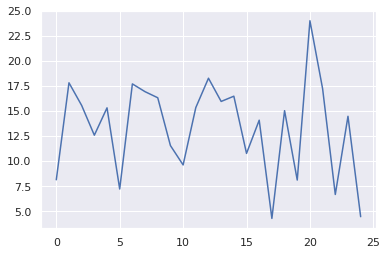

In [93]:
plt.plot(lrt_vals)

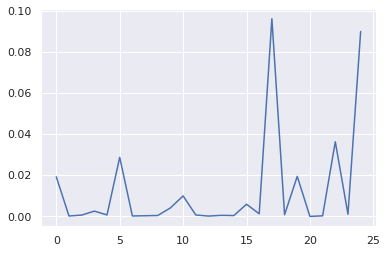

In [94]:
plt.plot(p_vals)

In [ ]:
np.a

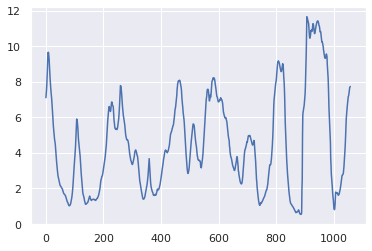

In [34]:
plt.plot(lrt_vals)

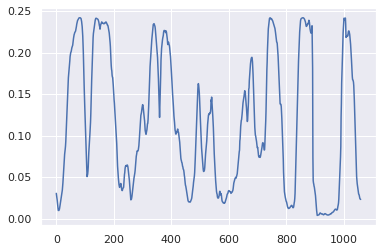

In [35]:
plt.plot(p_vals)